# Time Series Analysis - An Introduction

A time series is a sequence of measurements taken in order, usually at regular intervals. The order matters, and that is what makes time series different from the data we have looked at so far.

Some examples close to home:

- Daily active users of an app, recorded each day for a year.
- The hourly temperature in Kathmandu over the past month.
- Monthly sales of a small business.
- The number of GitHub commits to a project, counted per week.
- Heart-rate readings from a fitness tracker, recorded every second.

In all of these, today's value is usually related to yesterday's. That dependence between consecutive points is the single most important feature of time series, and most of the techniques in this notebook are built around it.

## What this notebook covers

1. What makes a time series different from ordinary data.
2. The four components: trend, seasonality, cyclical patterns, and noise.
3. Stationarity, and why it matters for forecasting.
4. Autocorrelation: how strongly today depends on yesterday.
5. Smoothing techniques: moving averages and exponential smoothing.
6. A small forecasting example.

We will not assume any prior exposure to time series. The aim is intuition first, with code to make it concrete.


## Setup

We will use NumPy, pandas, matplotlib, and a couple of helpers from statsmodels and scipy. Install with `pip install statsmodels` if needed.


In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

sns.set_theme(style="whitegrid")
plt.rcParams["figure.figsize"] = (10, 4)

rng = np.random.default_rng(42)

print("Libraries loaded.")


Libraries loaded.


## 1. What makes a time series different

In all the previous notebooks we treated each row of data as independent. The order of the rows did not matter. We could shuffle our exam scores or our Instagram users and the analysis would give the same answer.

For a time series, that is no longer true.

- The temperature today is correlated with the temperature yesterday.
- App users tomorrow are likely to be close to app users today.
- Weekly sales next week probably look like sales this week, plus some change.

This means we cannot use the standard "shuffle, split, train, test" workflow without thinking carefully. If we shuffle a time series, we destroy the structure that we are trying to learn from.

Two consequences follow:

1. We need new techniques that respect order, like moving averages and autocorrelation.
2. When we evaluate forecasting models, we always train on past data and test on *future* data, never the other way around.

Let us start by generating a small synthetic time series so we have something concrete to look at.


In [2]:
# A synthetic two-year daily time series with a trend, a yearly cycle, and noise.
days = pd.date_range(start="2024-01-01", end="2025-12-31", freq="D")
t = np.arange(len(days))

trend       = 0.05 * t                                 # slow upward drift
seasonality = 10 * np.sin(2 * np.pi * t / 365)         # one full cycle per year
noise       = rng.normal(0, 2, size=len(days))         # day-to-day random variation

values = 50 + trend + seasonality + noise              # final series
ts = pd.Series(values, index=days, name="visitors")

print(ts.head())
print(f"\nTotal length: {len(ts)} days")


2024-01-01    50.609434
2024-01-02    48.142165
2024-01-03    51.945119
2024-01-04    52.547326
2024-01-05    46.985954
Freq: D, Name: visitors, dtype: float64

Total length: 731 days


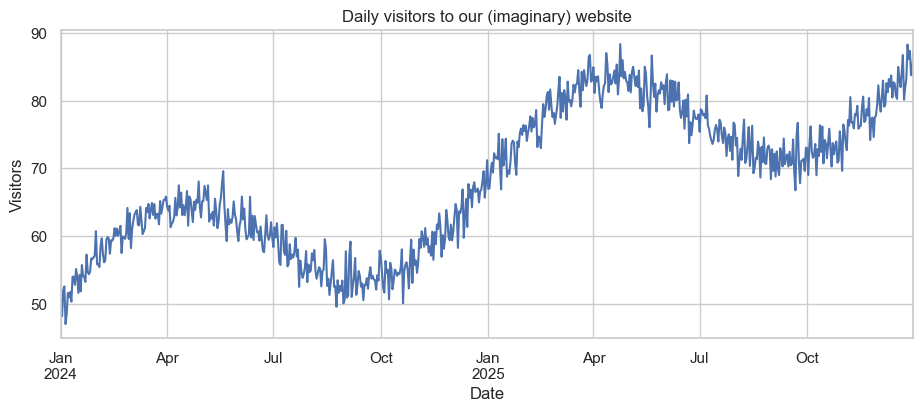

In [3]:
# A simple plot is the right starting point for any time series.
plt.figure(figsize=(11, 4))
ts.plot(color="#4C72B0")
plt.title("Daily visitors to our (imaginary) website")
plt.xlabel("Date")
plt.ylabel("Visitors")
plt.show()


Even from this single plot we can see two clear features: an overall upward drift, and a wave-like pattern that repeats once a year. This is exactly the kind of structure we will try to make explicit in the next section.


## 2. The four components of a time series

A useful mental model is that any time series can be decomposed into four pieces:

| Component | What it is | Example |
|-----------|------------|---------|
| Trend | A long-term upward or downward drift. | App users growing year on year. |
| Seasonality | A pattern that repeats over a fixed period. | Higher ice-cream sales every summer. |
| Cyclical | Patterns that repeat but without a fixed period. | Booms and recessions in the economy. |
| Irregular / noise | Random variation that is not explained by the rest. | A one-off spike from a viral tweet. |

There are two common ways to combine them:

- **Additive model:** `y(t) = trend + seasonality + noise`. Use this when the seasonal swings stay roughly the same size over time.
- **Multiplicative model:** `y(t) = trend * seasonality * noise`. Use this when seasonal swings get bigger as the trend grows.

In the synthetic series we just generated, we used an additive model. Let us pull the components apart visually.


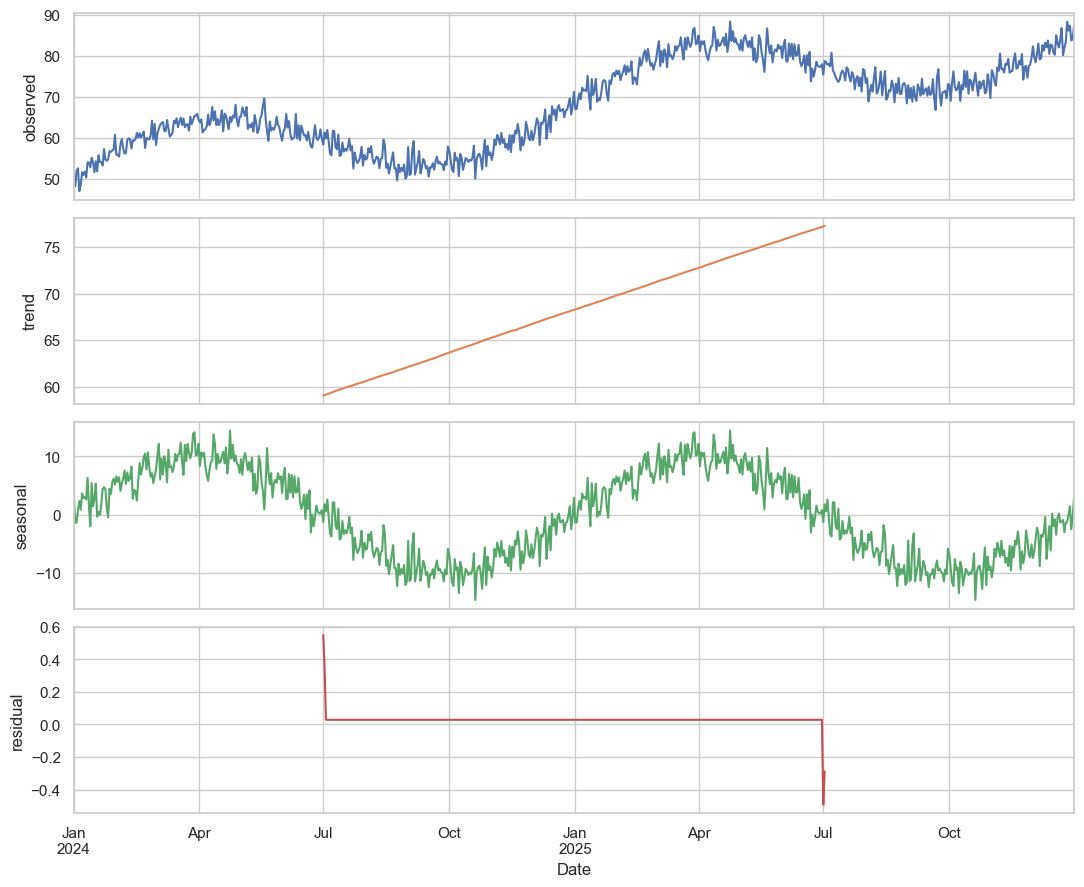

In [4]:
from statsmodels.tsa.seasonal import seasonal_decompose

decomposition = seasonal_decompose(ts, model="additive", period=365)

fig, axes = plt.subplots(4, 1, figsize=(11, 9), sharex=True)
decomposition.observed.plot(ax=axes[0], color="#4C72B0"); axes[0].set_ylabel("observed")
decomposition.trend.plot(ax=axes[1], color="#DD8452");    axes[1].set_ylabel("trend")
decomposition.seasonal.plot(ax=axes[2], color="#55A868"); axes[2].set_ylabel("seasonal")
decomposition.resid.plot(ax=axes[3], color="#C44E52");    axes[3].set_ylabel("residual")
axes[3].set_xlabel("Date")
plt.tight_layout()
plt.show()


The four panels show:

1. The original series.
2. The estimated long-term trend (a smooth upward line).
3. The estimated seasonal pattern (a clean wave, repeating once per year).
4. The residuals - what is left over after we remove trend and seasonality. If our model is good, this should look mostly like random noise.

This decomposition is one of the standard first steps in any time series project.


## 3. Stationarity

A time series is called **stationary** if its statistical properties do not change over time. Specifically:

- The mean stays roughly constant.
- The variance stays roughly constant.
- The relationship between values at different times depends only on the gap between them, not on the actual time.

Why does this matter? Most classical forecasting techniques assume stationarity. If a series has a strong trend, those techniques will mis-behave - because what was "average" a year ago is not "average" today.

The good news: even if a series is not stationary, we can often *make* it stationary by transforming it. The two most common transformations are:

- **Differencing:** instead of looking at the value, look at the change from one step to the next, `y(t) - y(t-1)`. This removes a linear trend.
- **Log transform:** take the logarithm of each value. This stabilises the variance when swings grow with the level.

Let us see this in practice.


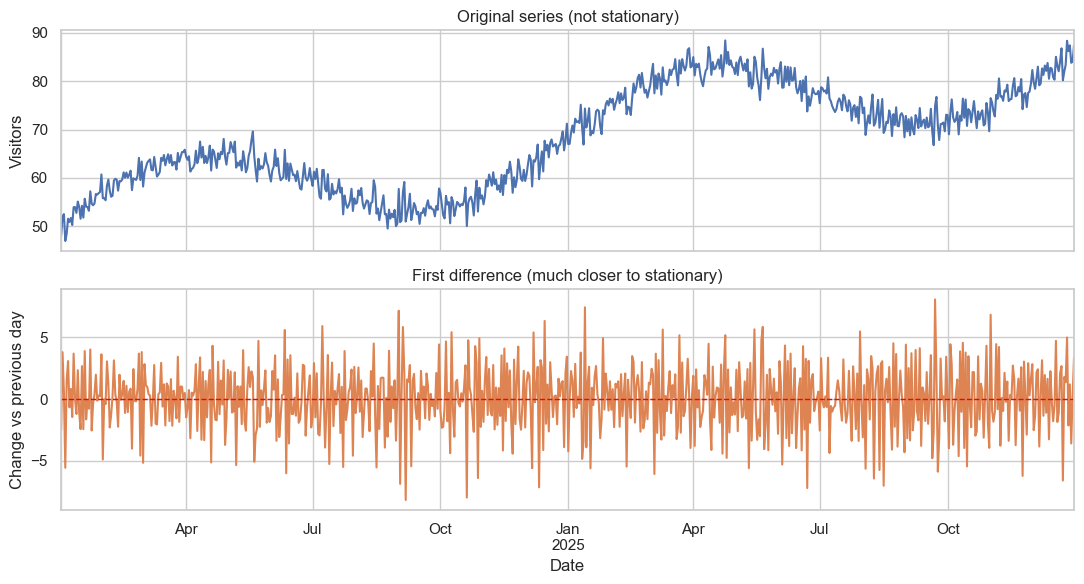

Mean of original series : 68.16
Mean of differenced     : 0.05  (close to zero, as expected)


In [5]:
# The original series is clearly not stationary - it drifts upward and has seasonality.
diffed = ts.diff().dropna()  # first difference: y(t) - y(t-1)

fig, axes = plt.subplots(2, 1, figsize=(11, 6), sharex=True)
ts.plot(ax=axes[0], color="#4C72B0")
axes[0].set_title("Original series (not stationary)")
axes[0].set_ylabel("Visitors")

diffed.plot(ax=axes[1], color="#DD8452")
axes[1].axhline(0, color="red", linestyle="--", linewidth=1)
axes[1].set_title("First difference (much closer to stationary)")
axes[1].set_ylabel("Change vs previous day")
axes[1].set_xlabel("Date")
plt.tight_layout()
plt.show()

print(f"Mean of original series : {ts.mean():.2f}")
print(f"Mean of differenced     : {diffed.mean():.2f}  (close to zero, as expected)")


The bottom plot looks much more like noise around zero. The trend is gone after a single differencing step. To remove the seasonality we would difference again at lag 365, but for our purposes this single differencing is enough to see the idea.

There is a formal test for stationarity called the **Augmented Dickey-Fuller (ADF) test**. If the p-value is below 0.05, we usually treat the series as stationary.


In [6]:
from statsmodels.tsa.stattools import adfuller

def adf_summary(name, series):
    stat, p, *_ = adfuller(series.dropna())
    verdict = "stationary" if p < 0.05 else "not stationary"
    print(f"{name:<20s}  ADF stat = {stat:7.3f}   p-value = {p:.4f}   -> {verdict}")

adf_summary("Original series", ts)
adf_summary("Differenced series", diffed)


Original series       ADF stat =  -0.805   p-value = 0.8178   -> not stationary
Differenced series    ADF stat = -16.170   p-value = 0.0000   -> stationary


## 4. Autocorrelation

Autocorrelation measures how strongly a series is correlated with a lagged version of itself.

- *Lag 1* autocorrelation: how much today depends on yesterday.
- *Lag 7* autocorrelation: how much today depends on a week ago.
- *Lag 365* autocorrelation: how much today depends on the same day a year ago.

If we plot the autocorrelation at many lags, we get an **autocorrelation function** (ACF). The ACF is one of the most useful diagnostic tools for time series.

What to look for:

- A slowly-decaying ACF suggests a strong trend.
- A spike at a particular lag suggests seasonality at that period.
- An ACF that drops to zero quickly suggests an essentially random series.


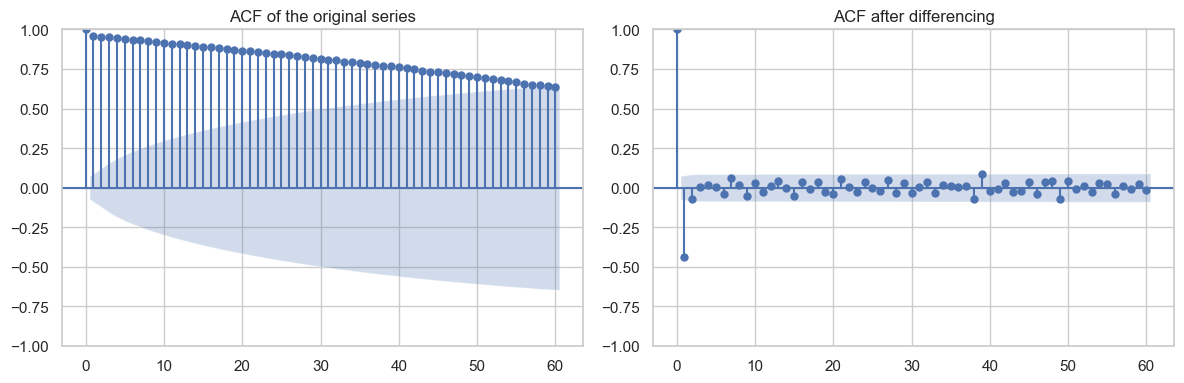

In [7]:
from statsmodels.graphics.tsaplots import plot_acf

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
plot_acf(ts, lags=60, ax=axes[0])
axes[0].set_title("ACF of the original series")

plot_acf(diffed, lags=60, ax=axes[1])
axes[1].set_title("ACF after differencing")
plt.tight_layout()
plt.show()


On the left, the ACF of the original series decays slowly and oscillates - clear signs of trend and seasonality. On the right, after differencing, the ACF drops off quickly and most lags are inside the blue confidence band, meaning the differenced series is much closer to white noise.

In short: the ACF tells us whether a series has memory, and how long that memory lasts.


## 5. Smoothing: moving averages and exponential smoothing

Smoothing is one of the simplest but most useful tools for time series. It removes short-term noise to make the underlying signal easier to see.

### 5.1 Simple moving average

A k-period moving average replaces each point with the average of the previous k points. Larger k means more smoothing, but also more lag.

### 5.2 Exponential smoothing

A moving average gives equal weight to each of the k recent values, then sharply forgets everything older. Exponential smoothing weights recent values more heavily and old values less heavily, in a smooth way:

`smoothed(t) = alpha * y(t) + (1 - alpha) * smoothed(t-1)`

The parameter alpha is between 0 and 1:

- alpha close to 1 means follow the data closely (little smoothing).
- alpha close to 0 means smooth heavily (slow to react to change).


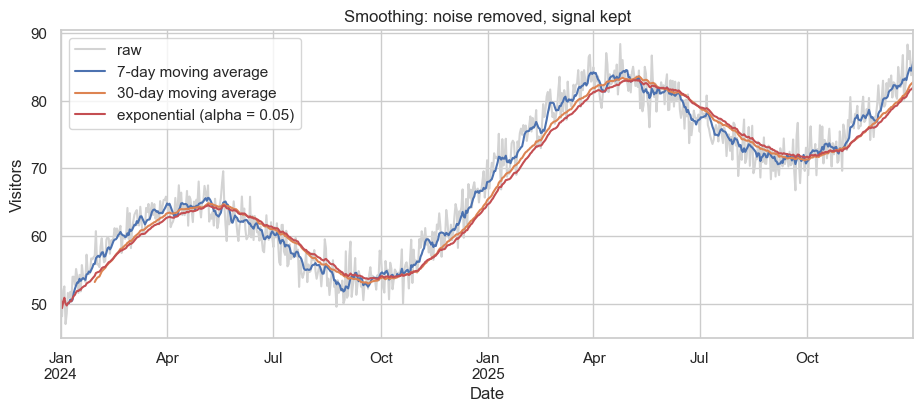

In [8]:
# Compute both kinds of smoothing on our daily visitors series.
ma_7  = ts.rolling(window=7).mean()      # one-week moving average
ma_30 = ts.rolling(window=30).mean()     # one-month moving average
ema   = ts.ewm(alpha=0.05).mean()        # exponential smoothing

plt.figure(figsize=(11, 4))
ts.plot(color="lightgrey", label="raw")
ma_7.plot(color="#4C72B0", label="7-day moving average")
ma_30.plot(color="#DD8452", label="30-day moving average")
ema.plot(color="#C44E52", label="exponential (alpha = 0.05)")
plt.title("Smoothing: noise removed, signal kept")
plt.xlabel("Date"); plt.ylabel("Visitors")
plt.legend()
plt.show()


Notice how the 30-day average is much smoother than the 7-day average, but lags further behind. Picking the right amount of smoothing is always a trade-off between clarity and responsiveness.


## 6. Splitting time series for evaluation

When we tested classification or regression models earlier in the course, we shuffled the data before splitting it. **For time series, never shuffle.** If we use future data to predict the past, we are cheating - the model will look much better than it really is.

The correct approach is a chronological split: train on the earlier portion of the series, test on the later portion.


Training set: 2024-01-01  to  2025-11-01  (671 days)
Test set    : 2025-11-02  to  2025-12-31   (60 days)


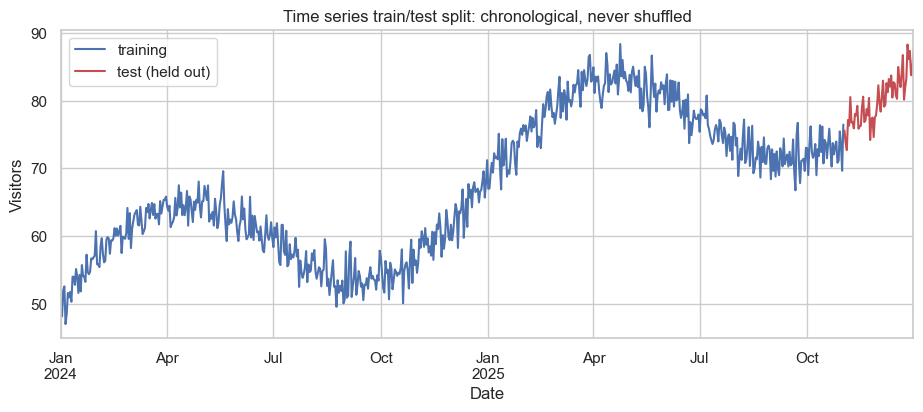

In [9]:
# Hold back the last 60 days as a test set.
split_point = len(ts) - 60
train, test = ts.iloc[:split_point], ts.iloc[split_point:]

print(f"Training set: {train.index.min().date()}  to  {train.index.max().date()}  ({len(train)} days)")
print(f"Test set    : {test.index.min().date()}  to  {test.index.max().date()}   ({len(test)} days)")

plt.figure(figsize=(11, 4))
train.plot(color="#4C72B0", label="training")
test.plot(color="#C44E52", label="test (held out)")
plt.title("Time series train/test split: chronological, never shuffled")
plt.xlabel("Date"); plt.ylabel("Visitors")
plt.legend()
plt.show()


## 7. A simple forecast

Let us try the simplest forecasting approach: take the average of the last week of training data, and predict that value for every day of the test period. We will then compare it to what actually happened.

This is intentionally crude. The point is to see the workflow end-to-end, not to win any forecasting competitions.


Naive forecast value : 73.02
Mean absolute error  : 7.06 visitors per day


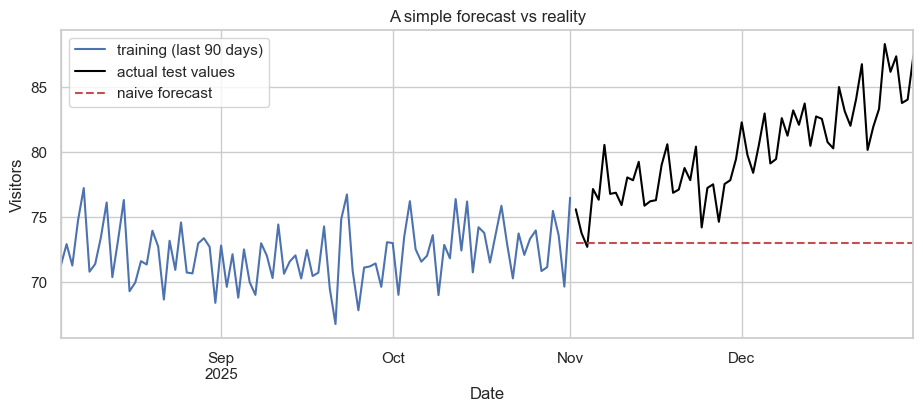

In [10]:
# A naive forecast: the mean of the last 7 days of training data.
forecast_value = train.iloc[-7:].mean()
forecast = pd.Series(forecast_value, index=test.index, name="forecast")

# Mean absolute error: the average size of our prediction mistakes.
mae = np.mean(np.abs(test.values - forecast.values))
print(f"Naive forecast value : {forecast_value:.2f}")
print(f"Mean absolute error  : {mae:.2f} visitors per day")

plt.figure(figsize=(11, 4))
train.iloc[-90:].plot(color="#4C72B0", label="training (last 90 days)")
test.plot(color="black", label="actual test values")
forecast.plot(color="#C44E52", linestyle="--", label="naive forecast")
plt.title("A simple forecast vs reality")
plt.xlabel("Date"); plt.ylabel("Visitors")
plt.legend()
plt.show()


The naive forecast misses the seasonal pattern entirely - it cannot, since it is just a flat line. A more capable model would account for the trend and the yearly cycle.

For real forecasting work, the most common families of models are:

- **ARIMA (AutoRegressive Integrated Moving Average):** classical, well-understood, good for many univariate problems.
- **Exponential smoothing (Holt-Winters):** fast, simple, handles trend and seasonality.
- **Prophet:** Facebook's library, designed for business time series with holidays and missing data.
- **Machine learning models (gradient boosting, neural networks):** flexible, but require care to handle the time-ordering correctly.

We will not go further into specific model families in this notebook; the aim here is to give you the vocabulary and intuition needed to study them later.


## 8. Common pitfalls

A short list of mistakes to watch out for when working with time series data:

1. **Shuffling the data before splitting.** This leaks future information into training. Always split chronologically.
2. **Ignoring missing dates.** A pandas time index can hide gaps. Always check that the index is regular before fitting models.
3. **Confusing correlation with causation.** Two unrelated series can both have an upward trend and look highly correlated. They are not necessarily related.
4. **Forgetting to check stationarity.** Many models assume it. Plot the series and look at the ACF before modelling.
5. **Reporting only training error.** Always evaluate on a held-out future period, not the data the model was trained on.
6. **Treating forecasts as certain.** A good forecast comes with a confidence interval, not just a single number.


## 9. Summary

The main ideas to remember from this notebook:

- Time series data is ordered, and that order carries information.
- Most series can be thought of as trend + seasonality + cyclical + noise.
- Stationary series are easier to model. We often achieve stationarity by differencing.
- Autocorrelation is the central diagnostic for time series; the ACF plot tells you a great deal at a glance.
- Smoothing (moving averages, exponential smoothing) helps reveal underlying patterns.
- Always split chronologically when evaluating forecasts.
- Even a very simple forecast is a useful baseline to beat.

### Where to go next

- Read about **ARIMA** models to formalise the trend + autoregression + moving-average ideas you saw here.
- Look into **Holt-Winters exponential smoothing** for series with both trend and seasonality.
- Learn about **vector autoregression (VAR)** when you have several related time series.
- For business-style data with holidays and irregular gaps, try the **Prophet** library.

A good way to deepen your intuition is to grab a real data source you care about - your phone's screen time history, a stock price you follow, daily commits on a public GitHub repository - and run through this entire notebook on it. Real data has surprises that synthetic data does not.
